Using basic logistic regression to predict the placement status of the student

In [3]:
import numpy as np
import pandas as pd


### steps

0. Preprocess + EDA + Feature Selection
1. Extract input and output cols
2. Scale the values
3. Train test split
4. Train the model
5. Evaluate the model/ model selection
6. Deploy the model

In [4]:
df = pd.read_csv('placement.csv')
df.head(10)

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
5,5,7.1,48.0,1
6,6,5.7,143.0,0
7,7,5.0,63.0,0
8,8,6.1,156.0,0
9,9,5.1,66.0,0


Step 0. Preprocessing / EDA

In [5]:
df= df.iloc[:,1:] # removing the unneccessary columns


In [6]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [7]:
df.shape

(100, 3)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


so doesnot have any missing value 

Using matplotlib for the EDA 

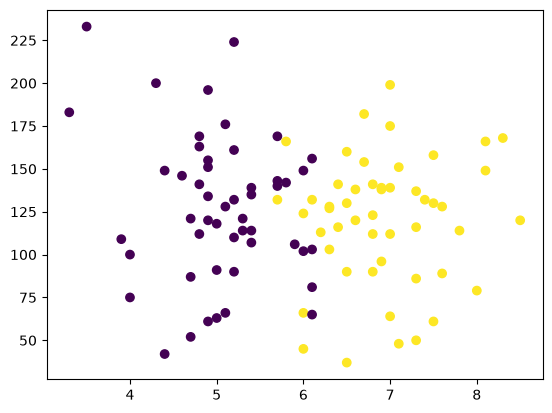

In [9]:
import matplotlib.pyplot as plt

plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

So we got the idea that we can use the logistic regression to separte the data points


Step 1 : Extract the input and output values: 

In [10]:
X= df.iloc[:,0:2]
y=df.iloc[:,-1]

In [11]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [12]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

Step 3: train test split

In [13]:
from sklearn.model_selection import train_test_split

X_train , X_test, y_train, y_test = train_test_split(X,y,test_size=0.1)

In [14]:
X_train

,cgpa,iq
46,5.3,114.0
41,5.4,114.0
11,6.9,138.0
38,6.5,160.0
29,7.0,112.0
...,...,...
83,7.5,130.0
87,5.7,132.0
40,4.9,134.0
65,8.1,166.0


In [15]:
y_train

46    0
41    0
11    1
38    1
29    1
     ..
83    1
87    1
40    0
65    1
72    1
Name: placement, Length: 90, dtype: int64

In [16]:
y_test

64    1
28    0
20    1
25    0
92    0
59    0
67    0
30    1
69    1
56    0
Name: placement, dtype: int64

Scaling the data values: 

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

In [18]:
X_train

array([[-0.60175903, -0.29605223],
       [-0.51312022, -0.29605223],
       [ 0.81646193,  0.29605223],
       [ 0.46190669,  0.83881465],
       [ 0.90510074, -0.34539427],
       [ 1.34829479,  0.78947262],
       [-1.04495309,  0.91282771],
       [-1.84270238, -0.41940733],
       [-0.77903666,  1.23355096],
       [ 0.01871264, -1.48026116],
       [ 0.01871264, -0.59210446],
       [ 0.28462907,  0.02467102],
       [-0.51312022,  0.32072325],
       [ 1.79148884, -1.15953791],
       [ 0.19599026, -0.32072325],
       [ 0.28462907, -0.56743344],
       [-1.22223071,  0.49342039],
       [ 1.17101717, -1.87499746],
       [ 0.90510074,  0.32072325],
       [ 0.5505455 ,  0.29605223],
       [-0.51312022,  0.22203917],
       [-0.95631428, -1.60361625],
       [ 1.88012765,  0.56743344],
       [ 0.99373955,  0.61677548],
       [-0.15856498,  0.98684077],
       [-0.86767547, -1.55427421],
       [-0.77903666, -1.48026116],
       [ 0.46190669, -2.19572071],
       [ 2.05740528,

In [19]:
X_test = scaler.transform(X_test)

X_test


array([[ 0.90510074, -1.52960319],
       [-0.69039785, -0.88815669],
       [ 0.5505455 , -0.14802612],
       [-0.86767547, -0.86348567],
       [-0.69039785, -0.39473631],
       [-1.04495309, -0.34539427],
       [-0.86767547, -0.19736815],
       [ 1.4369336 ,  0.04934204],
       [ 2.2346829 , -0.14802612],
       [ 0.10735145, -1.50493217]])

Training the model`

In [20]:
from sklearn.linear_model import LogisticRegression

clf= LogisticRegression()

In [21]:
# model training
clf.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

Evaluation of the model 

In [22]:
y_pred =clf.predict(X_test)
y_pred

array([1, 0, 1, 0, 0, 0, 0, 1, 1, 1])

In [23]:
y_test

64    1
28    0
20    1
25    0
92    0
59    0
67    0
30    1
69    1
56    0
Name: placement, dtype: int64

In [24]:
from sklearn.metrics import accuracy_score

In [25]:
accuracy_score(y_test,y_pred)

0.9

Plotting the ml pattern foundings. 

In [26]:
from mlxtend.plotting import plot_decision_regions  # using the mlxtend libraray to visualize the decision classifiers created during the training


<Axes: >

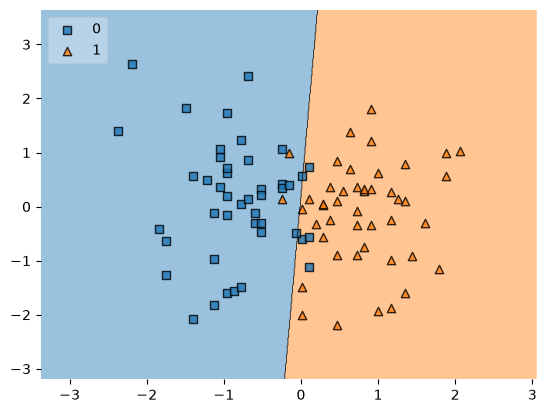

In [27]:
plot_decision_regions(X_train,y_train.values ,clf = clf, legend=2)  # classifier is clf and it takes the X,y as the np arrays so converting the y_train as the np arrays using the .values. 

Exporting the model 

In [28]:
import pickle

pickle.dump( clf, open('model.pkl' , 'wb'))  # so we exported our classifier the model using the pickle library 